# Training Positions Dataset Explorer
Visualizes `training_positions_enriched.jsonl`

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from collections import Counter

# Load data
records = []
with open('training_positions_enriched.jsonl') as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame([
    {
        'fen': r['fen'],
        'move_number': r['move_number'],
        'piece_count': r['piece_count'],
        'side_to_move': r['side_to_move'],
        'phase': r['phase'],
        'category': r['category'],
        'balance': r['balance'],
        'tag': r['tag'],
        'opening': r['source_game']['opening'],
        'eco': r['source_game']['eco'],
        'white_elo': int(r['source_game'].get('white_elo') or 0),
        'black_elo': int(r['source_game'].get('black_elo') or 0),
        'eval_depth': r['eval']['depth'],
        'best_cp': r['spreads']['best_cp'],
        'spread_1_2': r['spreads']['spread_1_2'],
        'spread_1_3': r['spreads']['spread_1_3'],
        'spread_1_5': r['spreads']['spread_1_5'],
        'num_pvs': len(r['eval']['pvs']),
        'mobility': r['features']['mobility'],
        'captures': r['features']['captures'],
        'checks': r['features']['checks'],
        'blocked_pawns': r['features']['blocked_pawns'],
    }
    for r in records
])

# Filter obvious outliers in ELO
df['avg_elo'] = (df['white_elo'] + df['black_elo']) / 2
df['avg_elo'] = df['avg_elo'].replace(0, np.nan)

print(f"Loaded {len(df):,} positions")
df.head(3)

Loaded 14,998 positions


,fen,move_number,piece_count,side_to_move,phase,category,balance,tag,opening,eco,...,best_cp,spread_1_2,spread_1_3,spread_1_5,num_pvs,mobility,captures,checks,blocked_pawns,avg_elo
0,2rq1rk1/1p1nbppp/2p1p3/p6b/2PPp3/PP3NPP/1B2PPB...,14,30,white,middlegame,complex,equal,general,King's Indian Attack,A08,...,-38,35,52,262,10,28,0,0,0,2371.5
1,r1bqkb1r/pppnppp1/5n1p/3p2B1/3P4/P1N5/1PP1PPPP...,5,32,white,middlegame,balanced,equal,daily,Richter-Veresov Attack,D01,...,-19,16,29,44,10,34,3,0,1,2340.5
2,r2qkb1r/pppnpppp/5n2/3p4/6b1/5NP1/PPPPPPBP/RNB...,5,32,white,middlegame,balanced,equal,general,King's Indian Attack,A08,...,36,2,4,20,10,24,0,0,0,2368.0


## 1. Dataset Overview

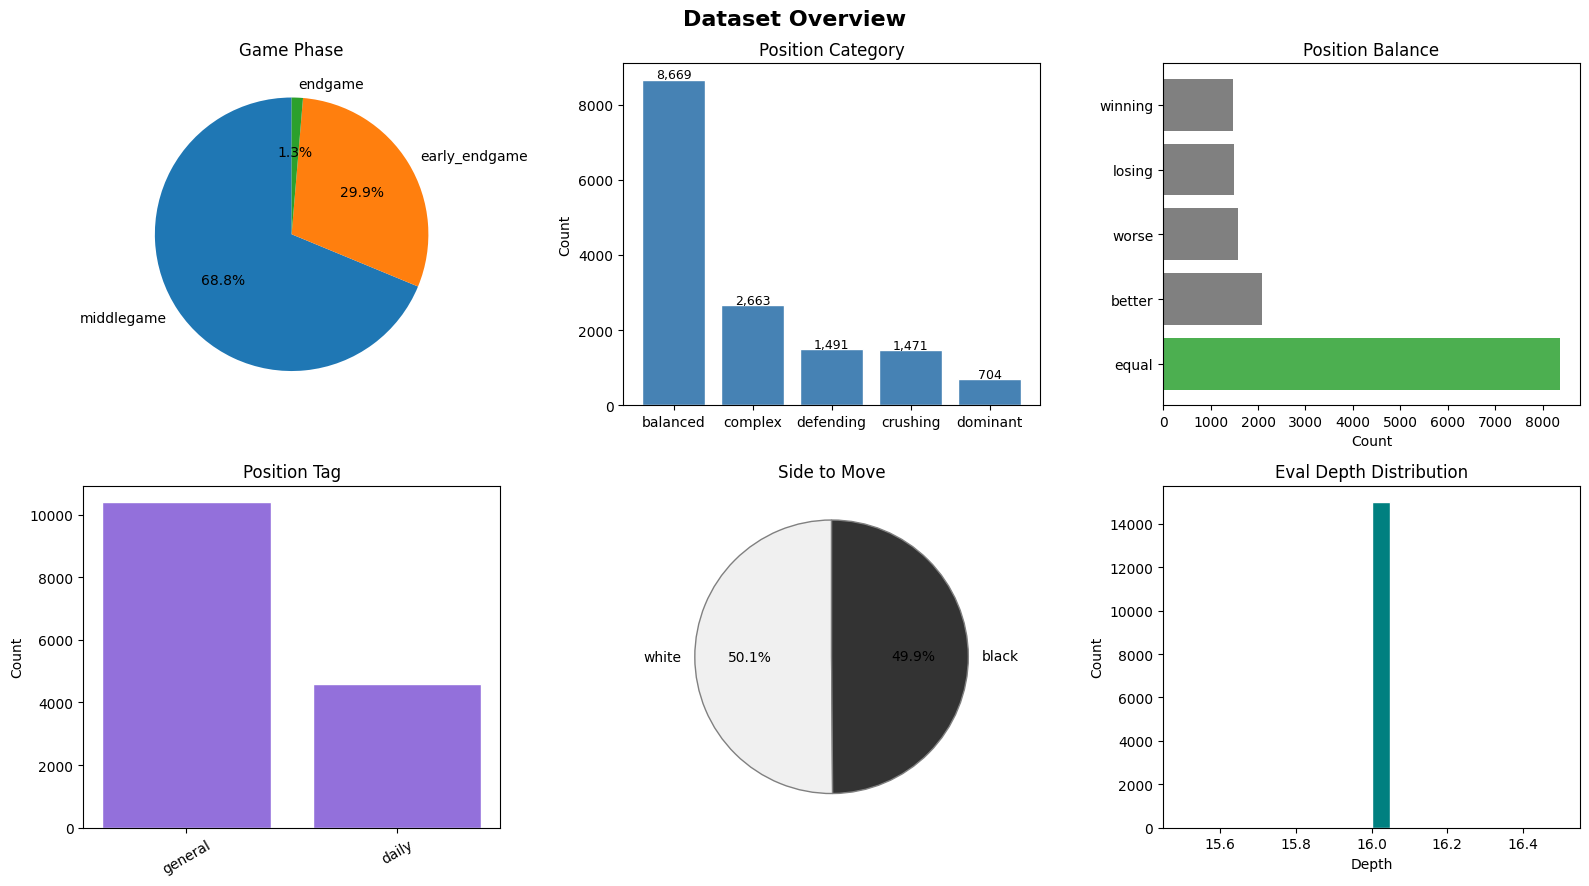

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold')

# Phase distribution
ax = axes[0, 0]
phase_counts = df['phase'].value_counts()
ax.pie(phase_counts, labels=phase_counts.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Game Phase')

# Category distribution
ax = axes[0, 1]
cat_counts = df['category'].value_counts()
bars = ax.bar(cat_counts.index, cat_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Position Category')
ax.set_ylabel('Count')
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{val:,}', ha='center', fontsize=9)

# Balance distribution
ax = axes[0, 2]
bal_counts = df['balance'].value_counts()
colors = {'equal': '#4CAF50', 'slight_white': '#2196F3', 'slight_black': '#FF9800',
          'white_advantage': '#1565C0', 'black_advantage': '#E65100',
          'winning_white': '#0D47A1', 'winning_black': '#BF360C'}
bar_colors = [colors.get(b, 'gray') for b in bal_counts.index]
ax.barh(bal_counts.index, bal_counts.values, color=bar_colors)
ax.set_title('Position Balance')
ax.set_xlabel('Count')

# Tag distribution
ax = axes[1, 0]
tag_counts = df['tag'].value_counts()
ax.bar(tag_counts.index, tag_counts.values, color='mediumpurple', edgecolor='white')
ax.set_title('Position Tag')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)

# Side to move
ax = axes[1, 1]
side_counts = df['side_to_move'].value_counts()
ax.pie(side_counts, labels=side_counts.index, autopct='%1.1f%%',
       colors=['#f0f0f0', '#333333'], startangle=90,
       wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
ax.set_title('Side to Move')

# Eval depth distribution
ax = axes[1, 2]
ax.hist(df['eval_depth'], bins=20, color='teal', edgecolor='white')
ax.set_title('Eval Depth Distribution')
ax.set_xlabel('Depth')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 2. Position Characteristics

C:\Users\alexs\AppData\Local\Temp\ipykernel_40256\524446152.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_phase, labels=phases, patch_artist=True)


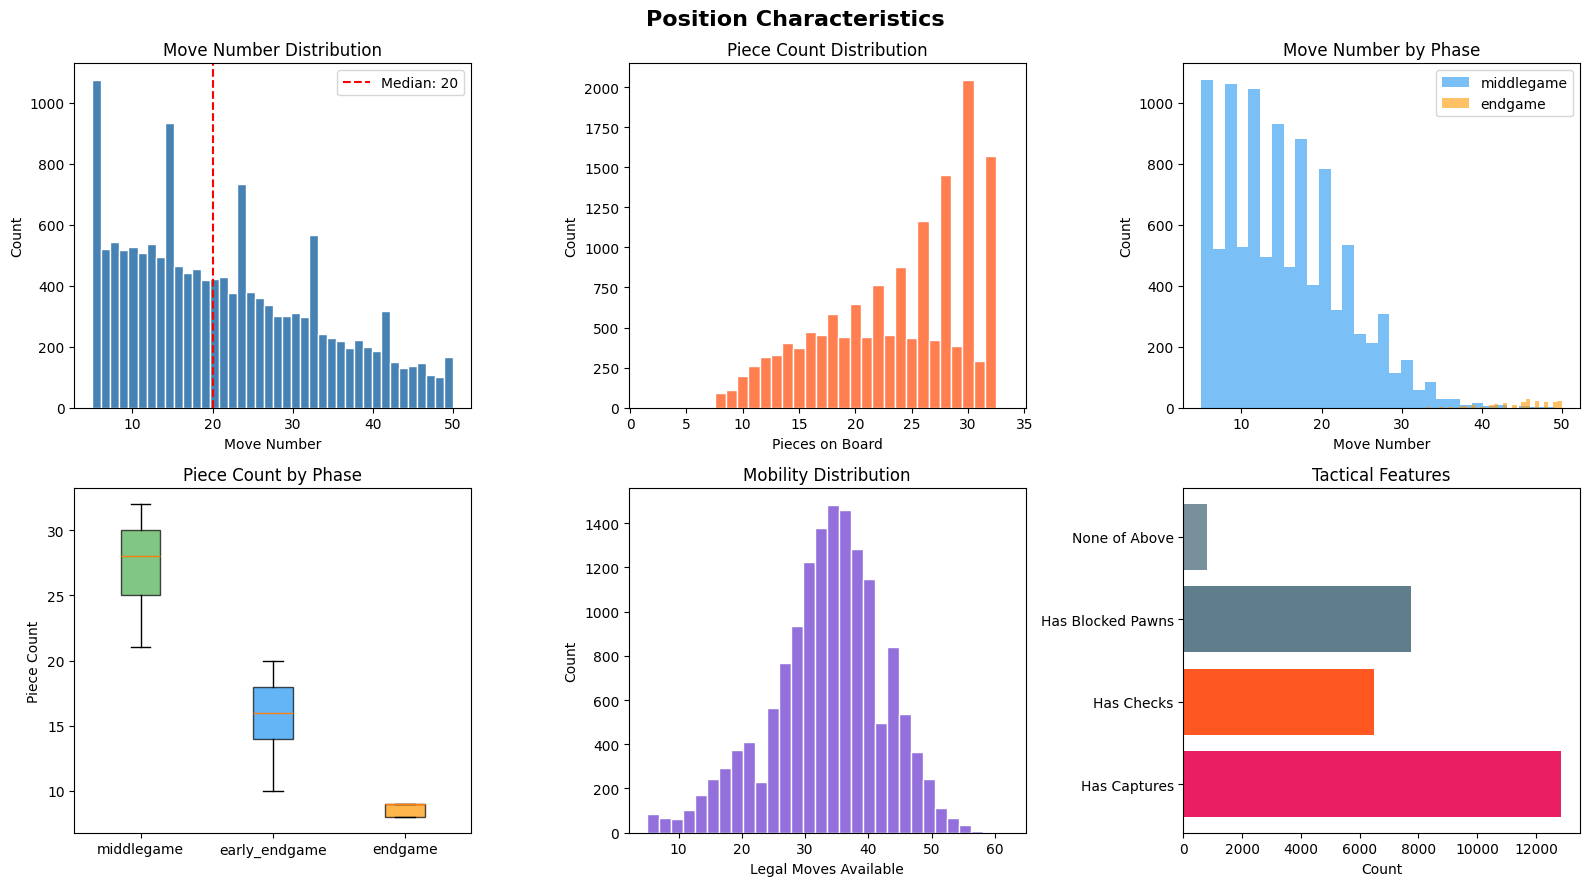

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Position Characteristics', fontsize=16, fontweight='bold')

# Move number distribution
ax = axes[0, 0]
ax.hist(df['move_number'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(df['move_number'].median(), color='red', linestyle='--', label=f'Median: {df["move_number"].median():.0f}')
ax.set_title('Move Number Distribution')
ax.set_xlabel('Move Number')
ax.set_ylabel('Count')
ax.legend()

# Piece count distribution
ax = axes[0, 1]
ax.hist(df['piece_count'], bins=range(2, 35), color='coral', edgecolor='white', align='left')
ax.set_title('Piece Count Distribution')
ax.set_xlabel('Pieces on Board')
ax.set_ylabel('Count')

# Move number by phase
ax = axes[0, 2]
for phase, color in [('opening', '#4CAF50'), ('middlegame', '#2196F3'), ('endgame', '#FF9800')]:
    subset = df[df['phase'] == phase]['move_number']
    if len(subset) > 0:
        ax.hist(subset, bins=30, alpha=0.6, label=phase, color=color)
ax.set_title('Move Number by Phase')
ax.set_xlabel('Move Number')
ax.set_ylabel('Count')
ax.legend()

# Piece count by phase (boxplot)
ax = axes[1, 0]
phases = df['phase'].unique()
data_by_phase = [df[df['phase'] == p]['piece_count'].values for p in phases]
bp = ax.boxplot(data_by_phase, labels=phases, patch_artist=True)
colors_phase = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
for patch, color in zip(bp['boxes'], colors_phase):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Piece Count by Phase')
ax.set_ylabel('Piece Count')

# Mobility distribution
ax = axes[1, 1]
ax.hist(df['mobility'], bins=30, color='mediumpurple', edgecolor='white')
ax.set_title('Mobility Distribution')
ax.set_xlabel('Legal Moves Available')
ax.set_ylabel('Count')

# Features: captures, checks, blocked_pawns
ax = axes[1, 2]
feature_data = {
    'Has Captures': (df['captures'] > 0).sum(),
    'Has Checks': (df['checks'] > 0).sum(),
    'Has Blocked Pawns': (df['blocked_pawns'] > 0).sum(),
    'None of Above': ((df['captures'] == 0) & (df['checks'] == 0) & (df['blocked_pawns'] == 0)).sum()
}
ax.barh(list(feature_data.keys()), list(feature_data.values()), color=['#E91E63', '#FF5722', '#607D8B', '#78909C'])
ax.set_title('Tactical Features')
ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

## 3. Evaluation Analysis

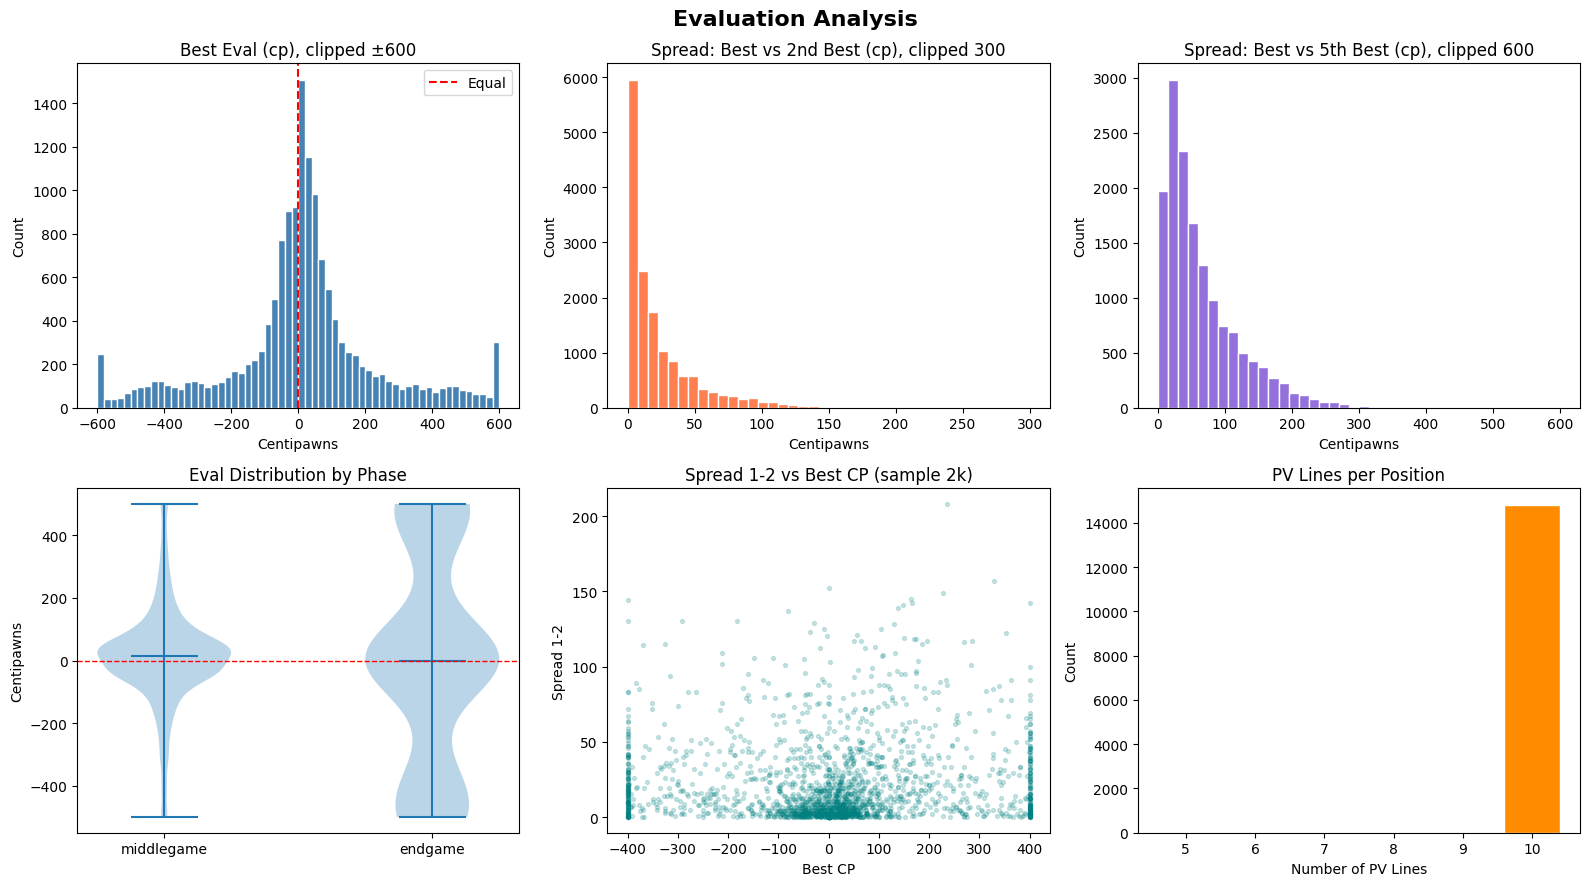

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Evaluation Analysis', fontsize=16, fontweight='bold')

# Clip cp for readability
cp_clipped = df['best_cp'].clip(-600, 600)

# Best CP distribution
ax = axes[0, 0]
ax.hist(cp_clipped, bins=60, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equal')
ax.set_title('Best Eval (cp), clipped ±600')
ax.set_xlabel('Centipawns')
ax.set_ylabel('Count')
ax.legend()

# Spread 1-2
ax = axes[0, 1]
spread_clipped = df['spread_1_2'].clip(0, 300)
ax.hist(spread_clipped, bins=40, color='coral', edgecolor='white')
ax.set_title('Spread: Best vs 2nd Best (cp), clipped 300')
ax.set_xlabel('Centipawns')
ax.set_ylabel('Count')

# Spread 1-5
ax = axes[0, 2]
spread5_clipped = df['spread_1_5'].clip(0, 600)
ax.hist(spread5_clipped, bins=40, color='mediumpurple', edgecolor='white')
ax.set_title('Spread: Best vs 5th Best (cp), clipped 600')
ax.set_xlabel('Centipawns')
ax.set_ylabel('Count')

# CP by phase (violin)
ax = axes[1, 0]
phase_order = [p for p in ['opening', 'middlegame', 'endgame'] if p in df['phase'].unique()]
cp_by_phase = [df[df['phase'] == p]['best_cp'].clip(-500, 500).values for p in phase_order]
vp = ax.violinplot(cp_by_phase, showmedians=True)
ax.set_xticks(range(1, len(phase_order)+1))
ax.set_xticklabels(phase_order)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Eval Distribution by Phase')
ax.set_ylabel('Centipawns')

# Spread vs CP scatter
ax = axes[1, 1]
sample = df.sample(min(2000, len(df)), random_state=42)
ax.scatter(sample['best_cp'].clip(-400, 400), sample['spread_1_2'].clip(0, 250),
           alpha=0.2, s=8, color='teal')
ax.set_title('Spread 1-2 vs Best CP (sample 2k)')
ax.set_xlabel('Best CP')
ax.set_ylabel('Spread 1-2')

# Number of PVs available
ax = axes[1, 2]
pv_counts = df['num_pvs'].value_counts().sort_index()
ax.bar(pv_counts.index.astype(str), pv_counts.values, color='darkorange', edgecolor='white')
ax.set_title('PV Lines per Position')
ax.set_xlabel('Number of PV Lines')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Game Source & ELO Analysis

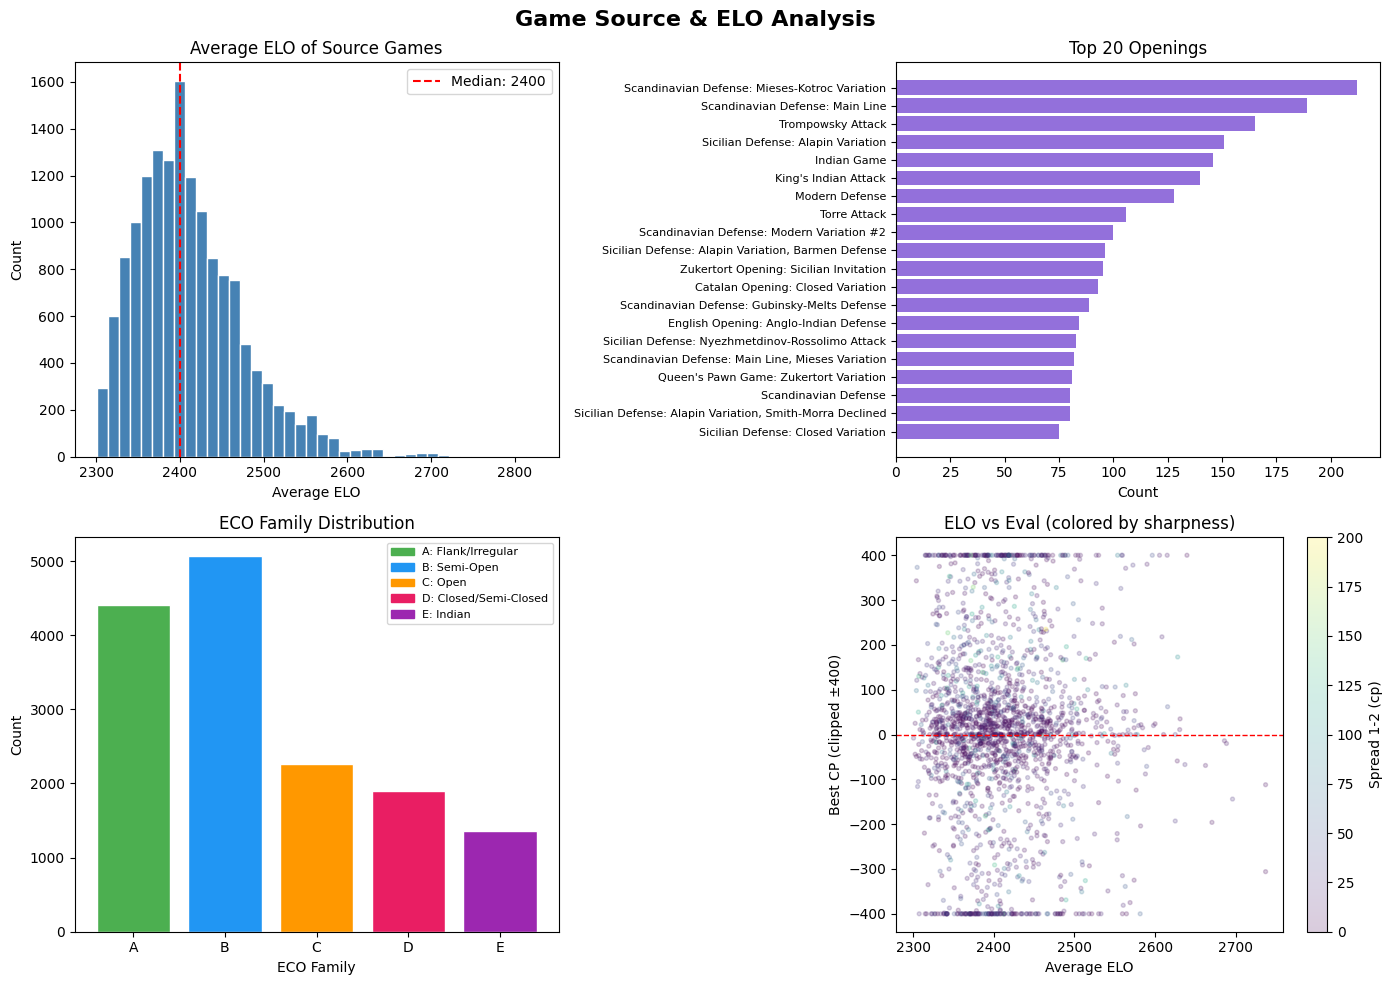

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Game Source & ELO Analysis', fontsize=16, fontweight='bold')

# ELO distribution
ax = axes[0, 0]
elo_valid = df['avg_elo'].dropna()
elo_valid = elo_valid[elo_valid > 500]  # remove 0s
ax.hist(elo_valid, bins=40, color='steelblue', edgecolor='white')
ax.axvline(elo_valid.median(), color='red', linestyle='--', label=f'Median: {elo_valid.median():.0f}')
ax.set_title('Average ELO of Source Games')
ax.set_xlabel('Average ELO')
ax.set_ylabel('Count')
ax.legend()

# Top 20 openings
ax = axes[0, 1]
top_openings = df['opening'].value_counts().head(20)
ax.barh(top_openings.index[::-1], top_openings.values[::-1], color='mediumpurple')
ax.set_title('Top 20 Openings')
ax.set_xlabel('Count')
ax.tick_params(axis='y', labelsize=8)

# ECO family distribution
ax = axes[1, 0]
eco_family = df['eco'].str[0].value_counts().sort_index()
eco_colors = {'A': '#4CAF50', 'B': '#2196F3', 'C': '#FF9800', 'D': '#E91E63', 'E': '#9C27B0'}
bar_colors = [eco_colors.get(k, 'gray') for k in eco_family.index]
bars = ax.bar(eco_family.index, eco_family.values, color=bar_colors, edgecolor='white')
ax.set_title('ECO Family Distribution')
ax.set_xlabel('ECO Family')
ax.set_ylabel('Count')
eco_names = {'A': 'A: Flank/Irregular', 'B': 'B: Semi-Open', 'C': 'C: Open', 'D': 'D: Closed/Semi-Closed', 'E': 'E: Indian'}
ax.legend([plt.Rectangle((0,0),1,1, color=eco_colors.get(k,'gray')) for k in eco_family.index],
          [eco_names.get(k, k) for k in eco_family.index], fontsize=8)

# ELO vs best_cp scatter
ax = axes[1, 1]
valid = df[(df['avg_elo'] > 500) & df['avg_elo'].notna()].sample(min(2000, len(df)), random_state=42)
sc = ax.scatter(valid['avg_elo'], valid['best_cp'].clip(-400, 400),
                alpha=0.2, s=8, c=valid['spread_1_2'].clip(0, 200), cmap='viridis')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
plt.colorbar(sc, ax=ax, label='Spread 1-2 (cp)')
ax.set_title('ELO vs Eval (colored by sharpness)')
ax.set_xlabel('Average ELO')
ax.set_ylabel('Best CP (clipped ±400)')

plt.tight_layout()
plt.show()

## 5. Cross-Cutting: Category × Phase × Balance Heatmap

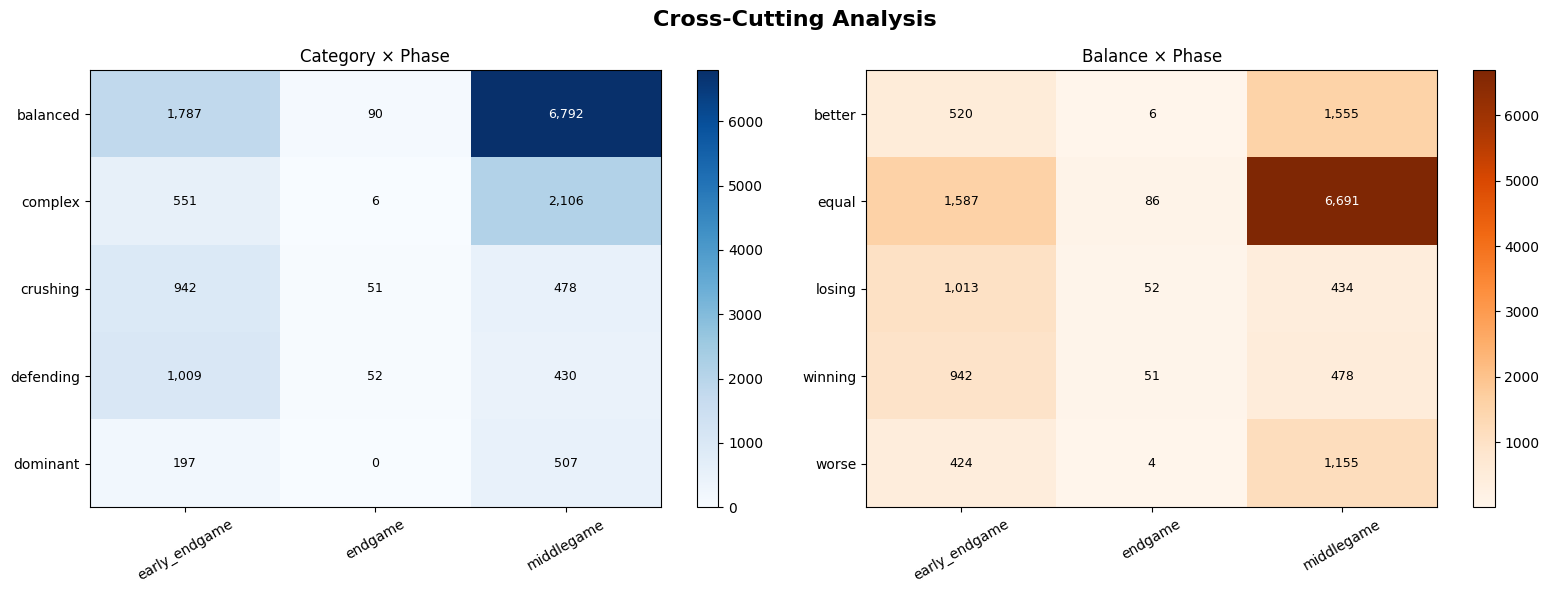

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cross-Cutting Analysis', fontsize=16, fontweight='bold')

# Category × Phase heatmap
ax = axes[0]
ct = pd.crosstab(df['category'], df['phase'])
im = ax.imshow(ct.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(ct.columns)))
ax.set_xticklabels(ct.columns, rotation=30)
ax.set_yticks(range(len(ct.index)))
ax.set_yticklabels(ct.index)
for i in range(len(ct.index)):
    for j in range(len(ct.columns)):
        ax.text(j, i, f'{ct.values[i, j]:,}', ha='center', va='center', fontsize=9,
                color='white' if ct.values[i, j] > ct.values.max()*0.5 else 'black')
ax.set_title('Category × Phase')
plt.colorbar(im, ax=ax)

# Balance × Phase heatmap
ax = axes[1]
ct2 = pd.crosstab(df['balance'], df['phase'])
im2 = ax.imshow(ct2.values, cmap='Oranges', aspect='auto')
ax.set_xticks(range(len(ct2.columns)))
ax.set_xticklabels(ct2.columns, rotation=30)
ax.set_yticks(range(len(ct2.index)))
ax.set_yticklabels(ct2.index)
for i in range(len(ct2.index)):
    for j in range(len(ct2.columns)):
        ax.text(j, i, f'{ct2.values[i, j]:,}', ha='center', va='center', fontsize=9,
                color='white' if ct2.values[i, j] > ct2.values.max()*0.5 else 'black')
ax.set_title('Balance × Phase')
plt.colorbar(im2, ax=ax)

plt.tight_layout()
plt.show()

## 6. Summary Statistics

In [8]:
print(f"{'='*50}")
print(f"  DATASET SUMMARY  ({len(df):,} positions)")
print(f"{'='*50}")

numeric_cols = ['move_number', 'piece_count', 'best_cp', 'spread_1_2', 'spread_1_5', 'mobility']
print(df[numeric_cols].describe().round(1).to_string())

print("\n--- Categorical Breakdown ---")
for col in ['phase', 'category', 'balance', 'tag', 'side_to_move']:
    counts = df[col].value_counts()
    print(f"\n{col}:")
    for k, v in counts.items():
        print(f"  {k:<25} {v:>6,}  ({100*v/len(df):.1f}%)")

  DATASET SUMMARY  (14,998 positions)
       move_number  piece_count  best_cp  spread_1_2  spread_1_5  mobility
count      14998.0      14998.0  14998.0     14998.0     14998.0   14998.0
mean          21.6         23.7     10.0        22.1        64.3      33.5
std           11.8          6.4    240.2        27.5        56.3       9.0
min            5.0          8.0  -1038.0         0.0         0.0       5.0
25%           12.0         19.0    -68.0         4.0        23.0      28.0
50%           20.0         25.0     10.0        11.5        46.0      34.0
75%           30.0         30.0     92.0        30.0        89.0      40.0
max           50.0         32.0   2578.0       480.0       798.0      62.0

--- Categorical Breakdown ---

phase:
  middlegame                10,313  (68.8%)
  early_endgame              4,486  (29.9%)
  endgame                      199  (1.3%)

category:
  balanced                   8,669  (57.8%)
  complex                    2,663  (17.8%)
  defending       